#### RAG indexing part -1 
Step 1: Load the documents
Step 2: Creating Chunks of text from the documents
Step 3: Embedding the chunks 
Step 4: Storing the embeddings in a vector store


The Process is called Ingestion. It involves loading documents, creating chunks of text from them, embedding the chunks, and storing the embeddings in a vector store.





##### Load document
https://python.langchain.com/docs/integrations/document_loaders/

In [18]:
from dotenv import load_dotenv
import os
load_dotenv()

GoogleGeminiKey = os.getenv('GOOGLE_GEMINI_KEY')

In [3]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("data/transformer_doc.txt")
documents = loader.load()
print(documents)


[Document(metadata={'source': 'data/transformer_doc.txt'}, page_content=' The dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. The best\nperforming models also connect the encoder and decoder through an attention\nmechanism. We propose a new simple network architecture, the Transformer,\nbased solely on attention mechanisms, dispensing with recurrence and convolutions\nentirely. Experiments on two machine translation tasks show these models to\nbe superior in quality while being more parallelizable and requiring significantly\nless time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-\nGerman translation task, improving over the existing best results, including\nensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task,\nour model establishes a new single-model state-of-the-art BLEU score of 41.8 after\ntraining for 3.5 days on eight GPUs, a small fraction o

In [4]:
## Website load
from langchain_community.document_loaders import WebBaseLoader
url = "https://huggingface.co/docs/transformers/en/model_doc/mllama"
loader = WebBaseLoader(url)
documents = loader.load()
documents

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://huggingface.co/docs/transformers/en/model_doc/mllama', 'title': 'Mllama', 'description': 'We’re on a journey to advance and democratize artificial intelligence through open source and open science.', 'language': 'No language found.'}, page_content='\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nMllama\n\n\n\n\n\n\n\n\nHugging Face\n\n\n\n\n\n\n\n\t\t\t\t\t\tModels\n\n\t\t\t\t\t\tDatasets\n\n\t\t\t\t\t\tSpaces\n\n\n\n\t\t\tCommunity\n\t\t\n\n\n\t\t\t\t\t\tDocs\n\n\t\t\t\t\t\tEnterprise\n\nPricing\n\t\t\t\n\n\n\n\n\n\nLog In\n\t\t\t\t\nSign Up\n\t\t\t\t\t\n\n\n\nTransformers documentation\n\t\t\t\nMllama\n\n\n\nTransformers\n\n🏡 View all docsAWS Trainium & InferentiaAccelerateAmazon SageMakerArgillaAutoTrainBitsandbytesChat UIDataset viewerDatasetsDiffusersDistilabelEvaluateGradioHubHub Python LibraryHuggingface.jsInference Endpoints (dedicated)Inference ProvidersLeaderboardsLightevalOptimumPEFTSafetensorsSentence TransformersTRLTasksText Embed

#### Splitting / Chunking the documents into smaller pieces of text


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = TextLoader("data/transformer_doc.txt")
documents = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=1024, chunk_overlap=264)

split_documents = splitter.split_documents(documents)
print(split_documents)


[Document(metadata={'source': 'data/transformer_doc.txt'}, page_content='The dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. The best\nperforming models also connect the encoder and decoder through an attention\nmechanism. We propose a new simple network architecture, the Transformer,\nbased solely on attention mechanisms, dispensing with recurrence and convolutions\nentirely. Experiments on two machine translation tasks show these models to\nbe superior in quality while being more parallelizable and requiring significantly\nless time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-\nGerman translation task, improving over the existing best results, including\nensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task,\nour model establishes a new single-model state-of-the-art BLEU score of 41.8 after\ntraining for 3.5 days on eight GPUs, a small fraction of

##### Language Splitting

In [7]:
from langchain_text_splitters import (Language,RecursiveCharacterTextSplitter)


PYTHON_CODE = """"
def hello_world():
    print("Hello World")

# Call the function
hello_world()
"""


python_splitter = RecursiveCharacterTextSplitter.from_language(language=Language.PYTHON, chunk_size=1024, chunk_overlap=264)
python_docs = python_splitter.create_documents([PYTHON_CODE])
python_docs




[Document(metadata={}, page_content='"\ndef hello_world():\n    print("Hello World")\n\n# Call the function\nhello_world()')]

##### Text Embeddings


In [15]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

model = GoogleGenerativeAIEmbeddings(model="models/embedding-001",google_api_key=GoogleGeminiKey)
embeddings = model.embed_documents(["Hello World", "Goodbye World"])
embeddings





[[0.05605072155594826,
  -0.0024490554351359606,
  -0.06547708064317703,
  -0.01089331042021513,
  0.06852371245622635,
  0.026035310700535774,
  0.023021932691335678,
  -0.0381924994289875,
  -0.009715992957353592,
  0.05284065753221512,
  -0.000989847001619637,
  0.030725674703717232,
  -0.0361834391951561,
  0.006391169968992472,
  0.0032818070612847805,
  -0.015474947169423103,
  0.030697975307703018,
  0.006488575134426355,
  0.020685365423560143,
  -0.0018162350170314312,
  0.014853945933282375,
  0.0003086265060119331,
  -0.003339721355587244,
  -0.014086122624576092,
  0.012543298304080963,
  0.0038018757477402687,
  0.016106491908431053,
  -0.04859350621700287,
  -0.02778564766049385,
  0.007844386622309685,
  -0.03847510367631912,
  -0.011622460559010506,
  -0.05066285654902458,
  0.018938496708869934,
  0.02620399370789528,
  -0.04141346365213394,
  0.0023054457269608974,
  0.008439337834715843,
  -0.009880712255835533,
  -0.0004038662591483444,
  0.01756339520215988,
  -0.0

In [16]:
loader = TextLoader("data/transformer_doc.txt")
documents = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001",google_api_key=GoogleGeminiKey)
docs_embeddings = embeddings.embed_documents([chunk.page_content for chunk in chunks])
docs_embeddings





[[0.0006322841509245336,
  -0.045066218823194504,
  -0.05590929836034775,
  0.05186305195093155,
  0.040019046515226364,
  0.031344421207904816,
  0.04466783627867699,
  0.0027576247230172157,
  0.0020994169171899557,
  0.017499864101409912,
  -0.009710906073451042,
  -0.008829045109450817,
  0.01165461353957653,
  -0.025932056829333305,
  0.015666155144572258,
  -0.01818297803401947,
  0.0002675796567928046,
  0.02412087470293045,
  -0.012673228979110718,
  -0.019581563770771027,
  0.009382628835737705,
  -0.018228795379400253,
  0.03317289799451828,
  -0.03453906998038292,
  -0.013159314170479774,
  -0.023834742605686188,
  0.01848948374390602,
  -0.0604119673371315,
  -0.06473755091428757,
  0.011465352028608322,
  -0.008749657310545444,
  0.02216903679072857,
  -0.027421073988080025,
  0.019945576786994934,
  0.016031010076403618,
  -0.021493658423423767,
  0.009589546360075474,
  0.018627671524882317,
  -0.02601083181798458,
  0.002325622597709298,
  0.030148908495903015,
  -0.013

In [ ]:
from langchain_postgres.vectorstores import PGVector
from langchain_community.document_loaders import TextLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
import uuid

raw_documents = TextLoader("data/transformer_doc.txt").load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
documents = text_splitter.split_documents(raw_documents)

embedding_model = GoogleGenerativeAIEmbeddings(model="models/embedding-001",google_api_key=GoogleGeminiKey)
connection = os.getenv("PG_CONNECTION_STRING")
db = PGVector.from_documents(documents,embedding_model,connection=connection)





In [23]:
new_documents = [
        Document(page_content="There is cat in the pond", metadata={"location":"pond","topic":"animal"}),
        Document(page_content="The dog is playing with a ball", metadata={"location":"yard","topic":"animal"}),
        Document(page_content="The sun is shining brightly outside", metadata={"location":"outside","topic":"weather"}),
        Document(page_content="It's raining heavily outside", metadata={"location":"outside","topic":"weather"}),
        Document(page_content="There are flowers blooming in the garden", metadata={"location":"garden","topic":"nature"}),
        Document(page_content="The sky is blue and clear", metadata={"location":"sky","topic":"weather"}),
        Document(page_content="There are birds singing in the trees", metadata={"location":"trees","topic":"nature"}),
        Document(page_content="The temperature is warm and comfortable outside", metadata={"location":"outside","topic":"weather"}),
        Document(page_content="It's a beautiful day outside", metadata={"location":"outside","topic":"weather"}),
        Document(page_content="There are clouds in the sky", metadata={"location":"sky","topic":"weather"}),
        Document(page_content="The sun is shining brightly", metadata={"location":"sky","topic":"weather"}),
        Document(page_content="There are butterflies flying around", metadata={"location":"outside","topic":"nature"}),
        Document(page_content="It's a nice day to go for a walk outside", metadata={"location":"outside","topic":"weather"}),
       Document(page_content="The flowers are blooming beautifully", metadata={"location":"outside","topic":"nature"}),
        Document(page_content="There is a bird singing in the tree", metadata={"location":"tree","topic":"nature"}),
        Document(page_content="It's a good time to go for a picnic outside", metadata={"location":"outside","topic":"weather"}),
        Document(page_content="The sky is clear and blue", metadata={"location":"sky","topic":"weather"})
    ]

ids = [str(uuid.uuid4()) for _ in documents]

db.add_documents(documents, ids=ids)



['feac7d3b-cd7b-4891-bdcb-bf7e9f03c547',
 'b4253206-30b1-4a49-bbd6-f91debb654d7',
 'f9374881-5849-4428-b678-851023d2daa9',
 '65abda24-60c1-4299-bced-6dcbc5578d16',
 'f3e30f99-f0d3-4789-82e9-21a5f57b2526',
 'a0f328aa-ba72-48b6-a1b4-83fa178731b4',
 '05353c5c-8419-4be1-a7ff-f01731728473']

#### SQL Record for optimize re-indexing

In [30]:
from langchain.indexes import SQLRecordManager,index
from langchain.docstore.document import Document

collection_name = "my_docs"
namespace = "my_docs_namespace"

vector_store = PGVector(
    embeddings=embedding_model,
    collection_name=collection_name,
    connection=connection,
    use_jsonb=True,
)

record_manager = SQLRecordManager(namespace,db_url=connection)

# Create schema if it doesn't exist
record_manager.create_schema()

# Create documents

docs = [
    Document(page_content="The sky is clear and blue", metadata={"id":"1","location":"sky","topic":"weather","source":"sky.txt"}),
    Document(page_content="It's a beautiful day outside.", metadata={"id":"2","location":"outside","topic":"nature","source":"day.txt"}),
    Document(page_content="The temperature is 75 degrees Fahrenheit.", metadata={"id":"3","location":"temperature","topic":"weather","source":"temp.txt"})

]

# Index the documents

index_1 = index(
    docs,
    record_manager,
    vector_store,
    cleanup="incremental", # prevent duplicate indexing
    source_id_key="source"  # use source field as a source identifier
)

print("Index attempt 1: ",index_1)

# Second attempt to index the documents, it will not add any document again

index_2 = index(
    docs,
    record_manager,
    vector_store,
    cleanup="incremental",
    source_id_key="source"
)

print("Index attempt 2: ",index_2)



Index attempt 1:  {'num_added': 3, 'num_updated': 0, 'num_skipped': 0, 'num_deleted': 0}
Index attempt 2:  {'num_added': 0, 'num_updated': 0, 'num_skipped': 3, 'num_deleted': 0}


In [32]:
# If we mutate a document, the new version will be written and old version sharing the same source.

docs[-1].page_content = "The temperature is now 76 degrees Fahrenheit."

index_3 = index(
    docs,
    record_manager,
    vector_store,
    cleanup="incremental",
    source_id_key="source"
)

print("Index attempt 3: ",index_3)


Index attempt 3:  {'num_added': 1, 'num_updated': 0, 'num_skipped': 2, 'num_deleted': 1}


### MultiVector Retriever

In [63]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai.embeddings import GoogleGenerativeAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langchain_core.rate_limiters import InMemoryRateLimiter


# init
connection = os.getenv("PG_CONNECTION_STRING")
collection_name = "summaries"
embedding_model = GoogleGenerativeAIEmbeddings(model="models/embedding-001",google_api_key=GoogleGeminiKey)


# load the pdf file
loader = PyMuPDFLoader('data/pocket book of economic indicator.pdf')
documents = loader.load()

# filter out empty documents
doc_filter =  lambda x: bool(x.page_content and x.page_content.strip())
filtered_docs = [doc for doc in documents if doc_filter(doc)]

## chunking
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(filtered_docs)

## Summary generation chain
prompt_text = "Summarize the following text:\n\n{doc}"
prompt = ChatPromptTemplate.from_template(prompt_text)
# rate_limiter = RateLimiter(max_calls=5, period=1)  # 5 calls per 1 second
rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.1,  # Allows 1 request every 10 seconds
    check_every_n_seconds=0.1,  # Checks every 100 ms
    max_bucket_size=10  # Maximum burst size
)

# llm = ChatGroq(groq_api_key = os.getenv('GROQ_KEY'),model='llama3-70b-8192',temperature=0)

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite", api_key=GoogleGeminiKey,temperature=0,rate_limiter=rate_limiter)

summary_chain = {"doc": lambda x: x.page_content} | prompt | llm | StrOutputParser()


summaries = summary_chain.batch(chunks, {"max_concurrency": 5})
print(summaries)


['This text is a copyright notice for "The Pocketbook Of Economic Indicators" published in 2002 by Enlace Maestro Inc. It states that all rights are reserved, meaning no part of the book can be reproduced without explicit written permission from both the author (Manuel Jesus-Backus) and the publisher. The notice also includes a disclaimer, stating that the author and publisher are not responsible for the completeness or accuracy of the book\'s content and are not liable for any damages resulting from its use.', 'This text disclaims all responsibility for any losses or damages resulting from using the information in the book.', 'This text is the table of contents for a reference guide titled "The Pocketbook Of Economic Indicators." It lists the contents, starting with an introduction and then detailing specific economic indicators, including the Beige Book, Chicago Purchasing Managers\' Index (PMI), Consumer Confidence Index, and Consumer Price Index (CPI).', 'This text is a table of co

In [72]:
filtered_docs[2],summaries[2]

(Document(metadata={'producer': 'Acrobat Distiller 5.0 (Windows)', 'creator': 'Acrobat PDFMaker 5.0 for Word', 'creationdate': '2002-09-26T22:04:32-05:00', 'source': 'data/pocket book of economic indicator.pdf', 'file_path': 'data/pocket book of economic indicator.pdf', 'total_pages': 39, 'format': 'PDF 1.4', 'title': 'Introduction', 'author': 'Windows', 'subject': '', 'keywords': '', 'moddate': '2002-10-15T20:51:43-05:00', 'trapped': '', 'encryption': 'Standard V1 R2 40-bit RC4', 'modDate': "D:20021015205143-05'00'", 'creationDate': "D:20020926220432-05'00'", 'page': 3}, page_content='The Pocketbook Of Economic Indicators \n \n \n_________________________________________________________________________ \n \n \nIntroduction \n \nIf you have no idea what CPI, PMI, or ECI mean, then you are like most beginning \ninvestors. Let me explain these and a few others terms to enhance your knowledge \nof indicators that affect your investments. \n \nEconomic indicators are used by the Federal Re

In [76]:
from langchain.storage import InMemoryStore
from pydantic import BaseModel
from langchain_core.runnables import RunnablePassthrough
from langchain.retrievers.multi_vector import MultiVectorRetriever
import uuid


# the vector store to use to index the child chunks
vector_store = PGVector(
    embeddings=embedding_model,
    collection_name=collection_name,
    connection=connection,
    use_jsonb=True,
)

# The storage layer for the parent documents
store = InMemoryStore()
id_key="doc_id"

# indexing the summaries in our vector store, whilst retaining the original
# documents in our document store:
retriever = MultiVectorRetriever( 
    vectorstore=vector_store,
    docstore=store,
    id_key=id_key,
)

# change from summaries to chunks since we need same length as docs
doc_ids = [str(uuid.uuid4()) for _ in chunks]

# Each summary is linked to the original document by doc_id
summary_doc = [
    Document(page_content=s,metadata={id_key:doc_ids[i]}) for i,s in enumerate(summaries)
]

# add the document summaries to the vector store for similarity search:
retriever.vectorstore.add_documents(summary_doc)

# Store the original document in the store, linked to the summaries via doc_id
# this allows us to first search summaries efficiently, then fetch the full docs when needed
retriever.docstore.mset(list(zip(doc_ids,chunks)))



In [78]:
sub_docs = retriever.vectorstore.similarity_search(query="Inflation Indicators",k=2)
print(sub_docs)

retriever.invoke("Inflation Indicators")


[Document(id='d1443c55-b97c-4d4e-9463-06222d3dad11', metadata={'doc_id': '39c3faea-d31f-499f-93c9-d30253485956'}, page_content='This guide, "The Pocketbook Of Economic Indicators," is designed for beginner investors unfamiliar with economic terms like CPI and PMI. It explains key economic indicators used by the Federal Reserve to monitor inflation and adjust interest rates. These rates, in turn, significantly impact borrowing, investment, and the overall health of the economy, with rising rates potentially slowing growth and falling rates potentially boosting it.'), Document(id='c50c73da-3b3b-477a-923a-5fa6b9bcfd2d', metadata={'doc_id': '3e19acf5-9780-4db6-8702-c79904a6faa6'}, page_content='This text is a table of contents or an index, listing various economic indicators and their corresponding page numbers. The indicators include:\n\n*   Consumer Price Index (CPI)\n*   Durable Goods Orders\n*   Employment Cost Index (ECI)\n*   Employment Situation\n*   Existing Home Sales\n*   Gross D

[Document(metadata={'producer': 'Acrobat Distiller 5.0 (Windows)', 'creator': 'Acrobat PDFMaker 5.0 for Word', 'creationdate': '2002-09-26T22:04:32-05:00', 'source': 'data/pocket book of economic indicator.pdf', 'file_path': 'data/pocket book of economic indicator.pdf', 'total_pages': 39, 'format': 'PDF 1.4', 'title': 'Introduction', 'author': 'Windows', 'subject': '', 'keywords': '', 'moddate': '2002-10-15T20:51:43-05:00', 'trapped': '', 'encryption': 'Standard V1 R2 40-bit RC4', 'modDate': "D:20021015205143-05'00'", 'creationDate': "D:20020926220432-05'00'", 'page': 3}, page_content='The Pocketbook Of Economic Indicators \n \n \n_________________________________________________________________________ \n \n \nIntroduction \n \nIf you have no idea what CPI, PMI, or ECI mean, then you are like most beginning \ninvestors. Let me explain these and a few others terms to enhance your knowledge \nof indicators that affect your investments. \n \nEconomic indicators are used by the Federal Re

#### RAPTOR

<function matplotlib.pyplot.show(close=None, block=None)>

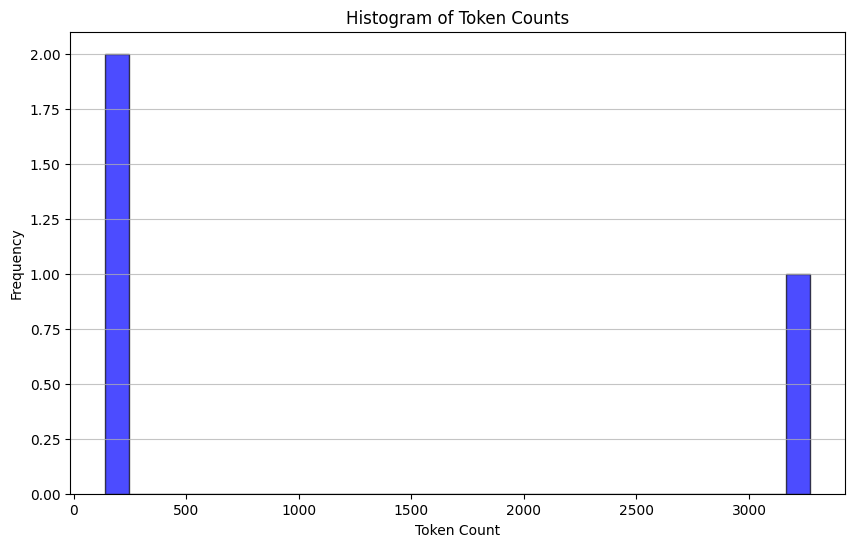

In [ ]:
import matplotlib.pyplot as plt
import tiktoken
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader

def num_tokens_from_string(string: str, encoding_name:str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# LCEL docs
url = "https://python.langchain.com/docs/expression_language/"
loader = RecursiveUrlLoader(url,max_depth=20,extractor=lambda x: Soup(x,"html.parser").text)
docs = loader.load()

# LCEL w/ PydanticOutputParser (outside the primary LCEL docs)
url = "https://python.langchain.com/docs/modules/model_io/output_parsers/quick_start"
loader = RecursiveUrlLoader(
    url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
)
docs_pydantic = loader.load()

# LCEL w/ Self Query (outside the primary LCEL docs)
url = "https://python.langchain.com/docs/modules/data_connection/retrievers/self_query/"
loader = RecursiveUrlLoader(
    url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
)
docs_sq = loader.load()

# Doc text 
docs.extend([*docs_pydantic, *docs_sq])
docs_text = [d.page_content for d in docs]

# calculate no. of token for each docuemnt
count = [num_tokens_from_string(d,"cl100k_base") for d in docs_text]

#plotting the histogram of token counts
plt.figure(figsize=(10,6))
plt.hist(count,bin=30,color="blue",edgecolor="black",alpha=0.7)
plt.title("Histogram of Token Counts in Documents")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


#### ColBERT

In [ ]:
from ragatouille import RAGPretrainedModel
import requests

RAG = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

